In [37]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import nist_helper
import io
from IPython.display import Image, display

In [48]:
lambda_tokens = ["nm", "wavelength", "wavelength_nm", "lambda", "lambda_nm", "wl", "wl_nm"]

int_tokens =["Grey Val", "grey val", "gray val", "grayscale", "gray value", "intensity", "signal", "counts", "value", "int", "rel. int.", "grey",]

major_locator = ticker.MultipleLocator(50)
minor_locator = ticker.MultipleLocator(10)

In [ ]:
def detect_nist_values(series, force_nist=None, nist_helper_module=nist_helper):

    s = series.astype(str).fillna("")
    numeric_fraction = float(pd.to_numeric(s, errors="coerce").notna().mean()) if len(s) else 0.0

    tokens = [t.lower() for t in getattr(nist_helper_module, "NIST_DESCRIPTORS", [])] if nist_helper_module else []
    token_pattern = "|".join(re.escape(t) for t in tokens if t)
    contains_tokens = bool(s.str.lower().str.contains(token_pattern, na=False).any()) if token_pattern else False
    contains_descriptor_chars = bool(s.str.contains(r"[A-Za-z*:\(\)\[\]/%]", na=False).any())

    if force_nist is True:
        has_any_nist = True

    elif force_nist is False:
        has_any_nist = False
        
    else:
        has_any_nist = bool(contains_tokens or (numeric_fraction < 0.6 and contains_descriptor_chars))

    return has_any_nist, {
        "numeric_fraction": numeric_fraction,
        "contains_tokens": contains_tokens,
        "contains_descriptor_chars": contains_descriptor_chars,
    }

In [51]:
def wavelength_to_rgb(wavelength, gamma=0.8):

    R, G, B = 0.0, 0.0, 0.0

    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = (1.0) ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    # Wavelengths outside 380-750 nm will be black (0,0,0) by default initialization

    # Ensure values are within 0-1 range
    return (max(0.0, min(1.0, R)), max(0.0, min(1.0, G)), max(0.0, min(1.0, B)))

In [40]:
def resolve_column(df, candidates, label):
    headers = [(str(col).strip(), str(col).strip().lower()) for col in df.columns]

    # Build a flat keyword list from all candidates.
    # Each candidate may be a phrase; we split on non-alphanumeric characters.
    keywords = []
    for candidate in candidates:
        text = str(candidate).strip().lower()
        if not text:
            continue
        parts = [part for part in re.split(r'[^a-z0-9]+', text) if part]
        keywords.extend(parts if parts else [text])

    # Prefer exact matches first, then keyword containment.
    for original, normalized in headers:
        for candidate in candidates:
            candidate_norm = str(candidate).strip().lower()
            if candidate_norm and normalized == candidate_norm:
                return original

    for original, normalized in headers:
        for keyword in keywords:
            if keyword and keyword in normalized:
                return original

    raise KeyError(f"Could not find a {label} column. Available columns: {list(df.columns)}")

In [4]:
def compute_label_positions(peak_nms, intensities=None, base_y=0.85, min_sep_nm=0.5, y_step=0.04, method="prefer_stronger_top", max_y=0.98):
    """
    Compute per-peak Y positions so labels for nearby peaks stack/stagger instead of overlapping.

    Args:
        peak_nms: list[float] - peak wavelengths (nm) in the same order you'll iterate peaks.
        intensities: optional list[float] - normalized intensities (same order), used by some methods.
        base_y: float - default label baseline (same as peak_label_y_position).
        min_sep_nm: float - minimum horizontal separation (nm) before labels considered "colliding".
        y_step: float - vertical step size to stack/stagger labels.
        method: "stack" | "stagger" | "prefer_stronger_top"
        max_y: float - clamp y so labels don't run off the top.

    Returns:
        list[float] - y position for each input peak (same order).
    """
    if not peak_nms:
        return []

    # prepare indices sorted by wavelength
    idx_sorted = sorted(range(len(peak_nms)), key=lambda i: peak_nms[i])
    result = [base_y] * len(peak_nms)

    # build clusters of peaks closer than min_sep_nm
    clusters = []
    cur = [idx_sorted[0]]
    for i in idx_sorted[1:]:
        if abs(peak_nms[i] - peak_nms[cur[-1]]) <= min_sep_nm:
            cur.append(i)
        else:
            clusters.append(cur)
            cur = [i]
    clusters.append(cur)

    for cluster in clusters:
        if len(cluster) == 1:
            result[cluster[0]] = base_y
            continue

        if method == "prefer_stronger_top" and intensities is not None:
            cluster_sorted = sorted(cluster, key=lambda k: -float(intensities[k]))
            n = len(cluster_sorted)
            if n == 1:
                result[cluster_sorted[0]] = base_y
            else:
                step = min(y_step, (max_y - base_y) / (n - 1))
                for pos, idx in enumerate(cluster_sorted):
                    result[idx] = base_y + pos * step

    return result

In [69]:
def prepare_generic_spectrum(df, intensity_col, apply_descriptor_adjustments=False):
    df = df.copy()
    df['_raw_int'] = pd.to_numeric(df[intensity_col], errors='coerce')
    df['_descriptor'] = ''
    df['_intensity_mult'] = 1.0
    df['_width_mult'] = 1.0
    df['_include'] = True
    df['_adj_int'] = df['_raw_int']
    return df

In [72]:
def plot_emission_spectrum(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0.12,
    x_min=400,
    x_max=750,
    fig_size=(15, 3),
    min_brightness=0.1,
    save_path=None,
    min_needle_max_width_nm=0.1,
    max_needle_max_width_nm=0.3,
    needle_shape_power=4,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    dpi=600,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_normalized_intensity=0.20,
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = resolve_column(data_df, lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = resolve_column(data_df, int_tokens, "intensity",)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data.empty
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print('NIST Destriptors Detected. Ending Generic Rendering.')
        return fig
    
    else:
        df_plot_data = prepare_generic_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig 

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    # Detection must always use raw numeric intensities; rendering uses adjusted values.
    detection_col = '_raw_int'
    int_col = '_adj_int'  # used for normalization/rendering
    
    # --- Peak Detection (raw data) ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[int_col], prominence=dynamic_prominence)

    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)

    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_minor_locator(minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    # Set a fixed y-range for the vertical lines to appear as a bar
    ax.set_ylim(0, 1)
   
    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=0.28, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        _peak_emphasis = 1.4
        final_intensity_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_intensity_scale = min(1.0, final_intensity_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_intensity_scale,
            base_rgb[1] * final_intensity_scale,
            base_rgb[2] * final_intensity_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_normalized_intensity:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=6,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    plt.title(f'Traditional Emission Spectrum Visualization ({mode.capitalize()} Mode)', color=text_color, y=1.0, pad=10)

    # Save the plot if a save_path is provided
    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    # Return the Figure for callers to save/close as desired
    return fig

In [38]:
def get_spectra(*args, save_path=None, headless=True, dpi=600, **kwargs):
    if headless:
        matplotlib.use('Agg')  # Switch to non-interactive backend for safe saving

    # Call the core function (does not close the figure)
    fig = plot_emission_spectrum(*args, **kwargs)

    # Wrapper-level save (preferred over internal saves)
    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    if headless:
        plt.close(fig)

    return fig

NIST Destriptors Detected. Ending Generic Rendering.


0

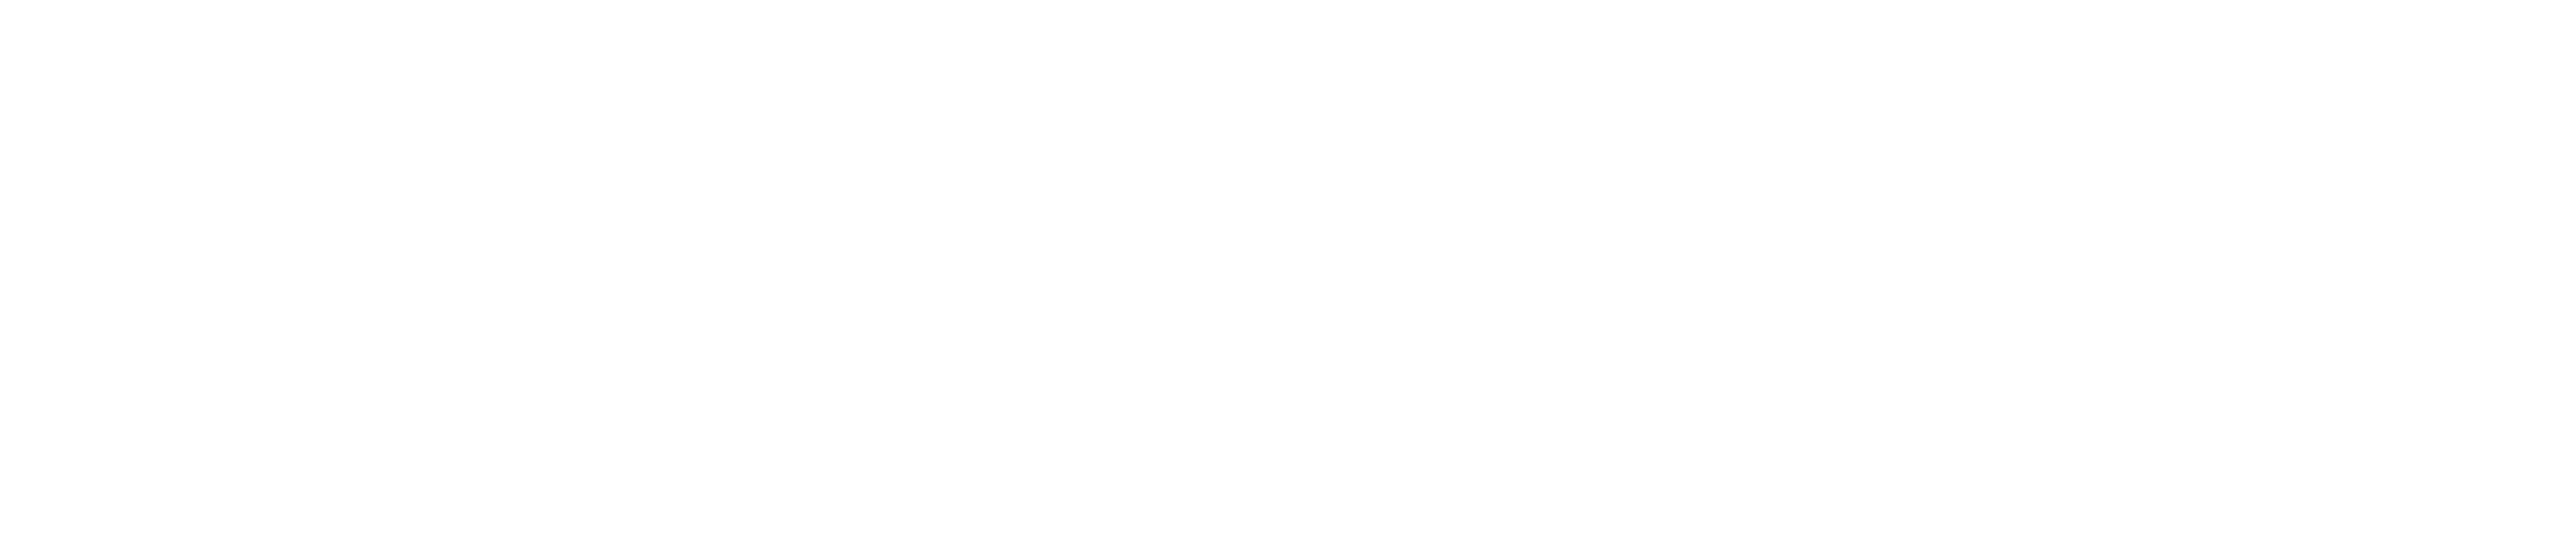

In [54]:
EXCEL_FILE_PATH = 'oxygen nist 2.xlsx'
MIN_WAVELENGTH = 400.0
MAX_WAVELENGTH = 750.0
LINE_THICKNESS = 0.1

# Example: load and render without editing the source module.
df = pd.read_excel(EXCEL_FILE_PATH)

fig = plot_emission_spectrum(
    data_df=df,
    prominence_percentage=0.08,
    x_min=MIN_WAVELENGTH,
    x_max=MAX_WAVELENGTH,
    min_needle_max_width_nm=LINE_THICKNESS,
    max_needle_max_width_nm=0.3,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    )

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)
buf.seek(0)

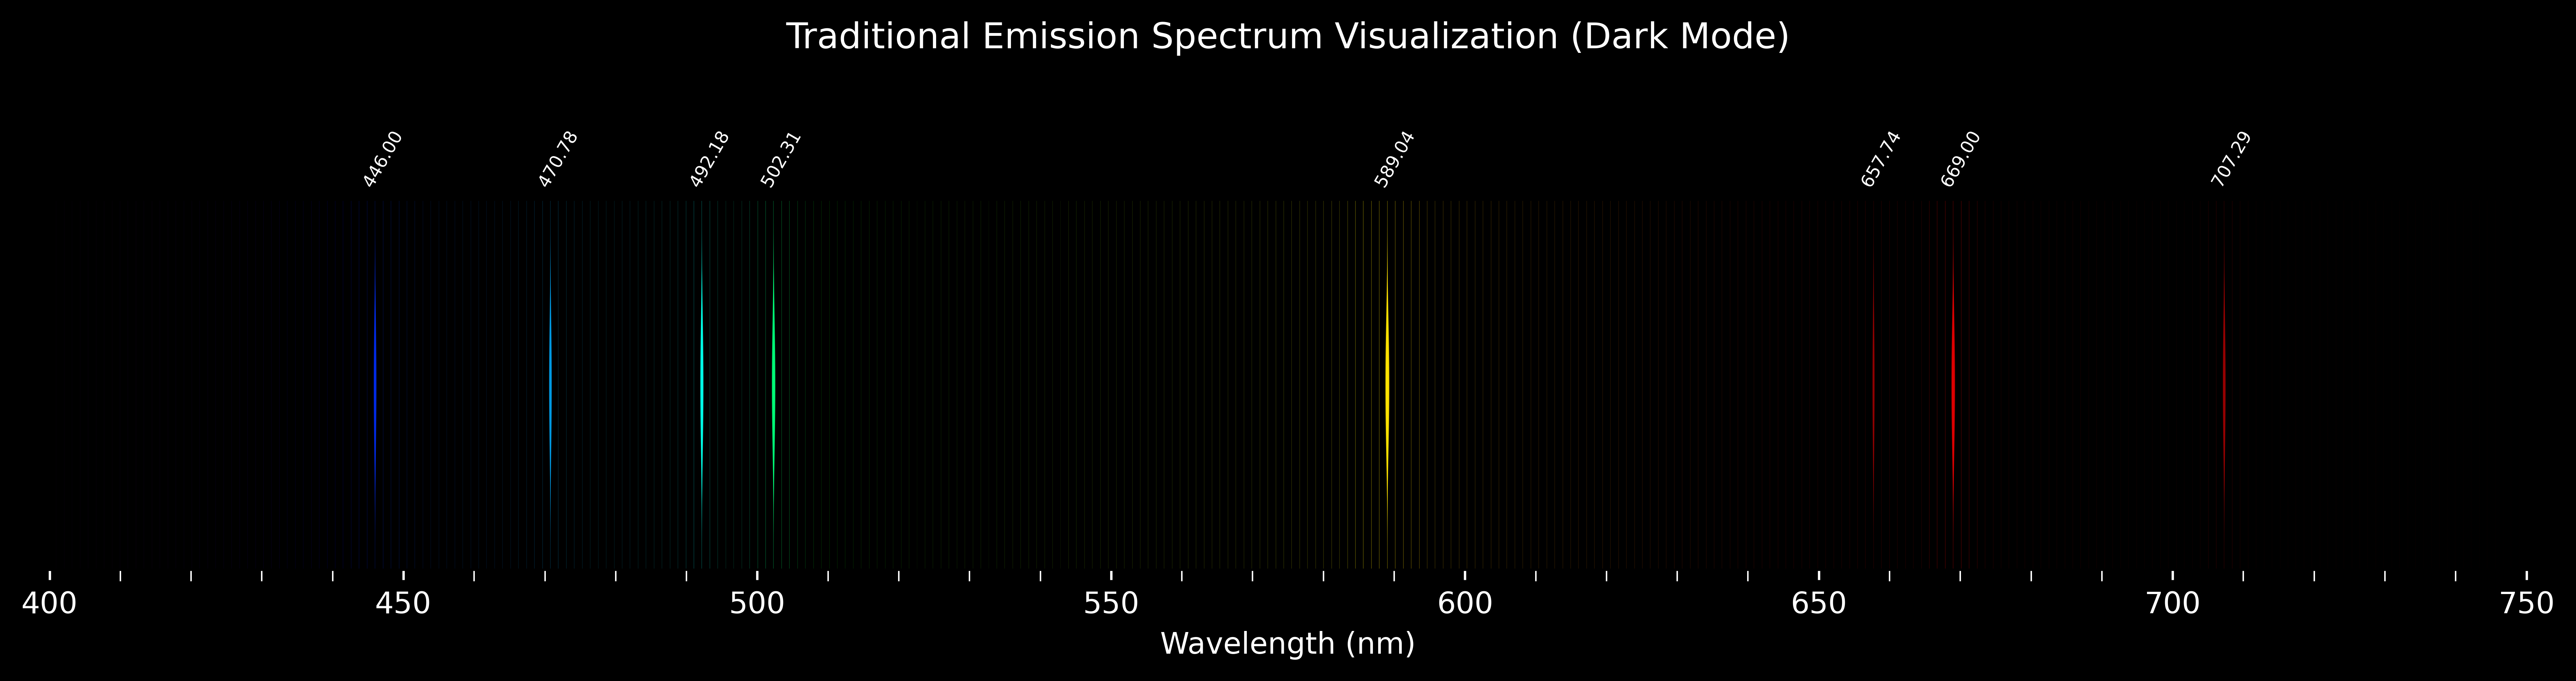

In [73]:
EXCEL_FILE_PATH = 'he test.xlsx'


# Example: load and render without editing the source module.
df = pd.read_excel(EXCEL_FILE_PATH)

fig = plot_emission_spectrum(
    data_df=df,
    prominence_percentage=0.08,
    min_needle_max_width_nm=0.1,
    max_needle_max_width_nm=0.3,
    glow_width_multiplier=1.3,
    glow_alpha=0.35,
    mode='dark',
    peak_label_y_position=0.77,
    max_needle_y_scale=0.75,
    )

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)